In [ ]:
#@title Instalação de Dependências

%%capture cap --no-stderr
!nvidia-smi # Drivers NVIDIA
!pip install -q diffusers # Biblioteca diffusers do HuggingFace
!pip install accelerate # Usado otimizar o uso de recursos computacionais, configurando o embiante automaticamente com base no hardware detectado. Mais informções: https://huggingface.co/docs/accelerate/quicktour
!pip install -U peft


In [ ]:
#@title Importação de Dependências

# Pipeline de Variação de Imagem Simples
from diffusers import StableDiffusionImageVariationPipeline
from PIL import Image
from io import BytesIO
import requests

# Pipeline de Imagem para Imagem do SDXL Turbo
from diffusers import AutoPipelineForImage2Image
from diffusers.utils import load_image, make_image_grid
from diffusers import AutoPipelineForText2Image
import torch

# Pipeline de Imagem para Imagem do SDXL Lightning
from diffusers import StableDiffusionXLPipeline, UNet2DConditionModel, EulerDiscreteScheduler
# from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

# Pipeline de Imagem para Imagem do Hyper SDXL
from diffusers import DiffusionPipeline, DDIMScheduler


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.10/dist-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)
/usr/local/lib/python3.10/dist-packages/diffusers/models/vq_model.py:20: FutureWarning: `VQEncoderOutput` is deprecated and will be removed in version 0.31. Importing `VQEncoderOutput` from `diffusers.models.vq_model` is deprecated and this will be removed in a future version. Please use `from diffusers.models.autoencoders.vq_model import VQEncoderOutput`, instead.
  deprecate("VQEncoderOutput", "0.31", deprecation_message)
/usr/local/lib/python3.10/dist-packages/diffusers/models/vq_model.py:25: FutureWarning

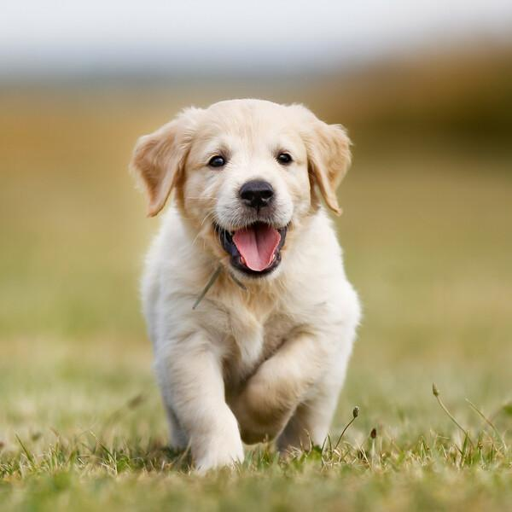

In [ ]:
#@title Imagem Inicial e Prompt

init_image = load_image("https://pbs.twimg.com/media/GJC7Ge5WMAMMXNQ.jpg")
init_image = init_image.resize((512, 512))

prompt = "dog running, 8k"
negative_prompt = "ugly, tiling, poorly drawn hands, poorly drawn feet, poorly drawn face, out of frame, extra limbs, disfigured, deformed, body out of frame, bad anatomy, watermark, signature, cut off, low contrast, underexposed, overexposed, bad art, beginner, amateur, distorted face, worst quality, normal quality, low quality"

init_image


In [ ]:
#@title Pipeline de Variação de Imagem Simples

%%timeit
%%capture imagevariationlog
pipe_variation = StableDiffusionImageVariationPipeline.from_pretrained(
    "lambdalabs/sd-image-variations-diffusers", revision="v2.0", use_safetensors=False
)

pipe_variation = pipe_variation.to("cuda")
# pipe_variation.enable_attention_slicing() # Menor Uso de VRAM ao custo de velocidade


23.8 s ± 1.07 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
#@title Geração - Pipeline de Variação de Imagem Simples

result_variation = pipe_variation(init_image, num_images_per_prompt=2, guidance_scale=9)


  0%|          | 0/50 [00:00<?, ?it/s]

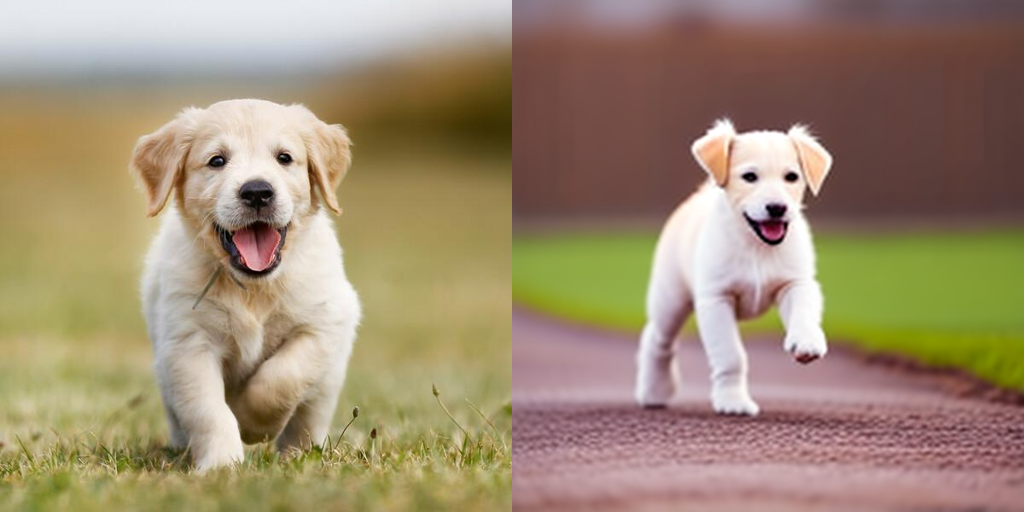

In [ ]:
#@title Resultado - Pipeline de Variação de Imagem Simples

make_image_grid([init_image, result_variation["images"][0]], rows=1, cols=2)


In [ ]:
#@title Pipeline de Imagem para Imagem do SDXL Turbo

# Pipelines
# %%timeit
%%capture sdxlturbolog
pipe_turbo_txt2img = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe_turbo_txt2img = pipe_turbo_txt2img.to("cuda")
pipe_turbo_img2img = AutoPipelineForImage2Image.from_pipe(pipe_turbo_txt2img).to("cuda")

# Otimização
# pipe_turbo_img2img.unet = torch.compile(pipe_turbo_img2img.unet, mode="reduce-overhead", fullgraph=True) # Compila r UNet encapsulada.
# pipe_turbo_img2img.upcast_vae() # Variational Autoencoder (VAE) é a técnica utilizada para codificar imagens em um espaço dimensional latente, o que irá influenciar na qualidade das novas imagens geradas da decodificação.

result_sdxlturbo = pipe_turbo_img2img(prompt, image=init_image, strength=0.5, guidance_scale=0.0, num_inference_steps=2).images[0]


  0%|          | 0/1 [00:00<?, ?it/s]

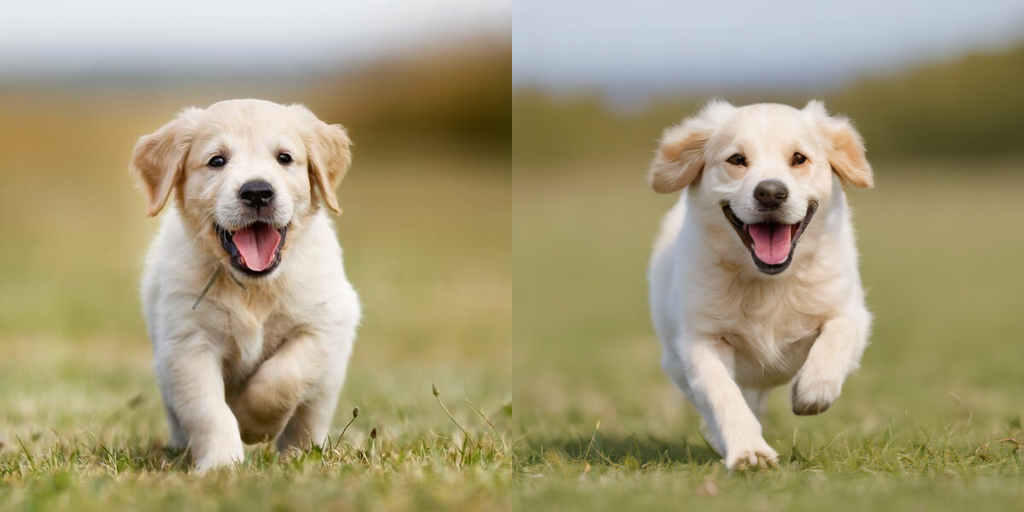

In [ ]:
#@title Resultado - Pipeline de Imagem para Imagem do SDXL Turbo

make_image_grid([init_image, result_sdxlturbo], rows=1, cols=2)


In [ ]:
#@title Pipeline de Imagem para Imagem do SDXL Lightning

# Carregamento do modelo
%%capture sdxllightning

base = "stabilityai/stable-diffusion-xl-base-1.0"
repo = "ByteDance/SDXL-Lightning"
ckpt = "sdxl_lightning_4step_unet.safetensors" # Use the correct ckpt for your step setting!

unet = UNet2DConditionModel.from_config(base, subfolder="unet").to("cuda", torch.float16)
unet.load_state_dict(load_file(hf_hub_download(repo, ckpt), device="cuda"))
pipe_lightning = StableDiffusionXLPipeline.from_pretrained(base, unet=unet, torch_dtype=torch.float16, variant="fp16").to("cuda")

# Ensure sampler uses "trailing" timesteps.
pipe_lightning.scheduler = EulerDiscreteScheduler.from_config(pipe_lightning.scheduler.config, timestep_spacing="trailing")

# Otimização
pipe_lightning.enable_attention_slicing()
pipe_lightning.unet = torch.compile(pipe_lightning.unet, mode="reduce-overhead", fullgraph=True)
pipe_lightning.upcast_vae()

# Ensure using the same inference steps as the loaded model and CFG set to 0.
# pipe("A girl smiling", num_inference_steps=4, guidance_scale=0).images[0].save("output.png")


  0%|          | 0/3 [00:00<?, ?it/s]

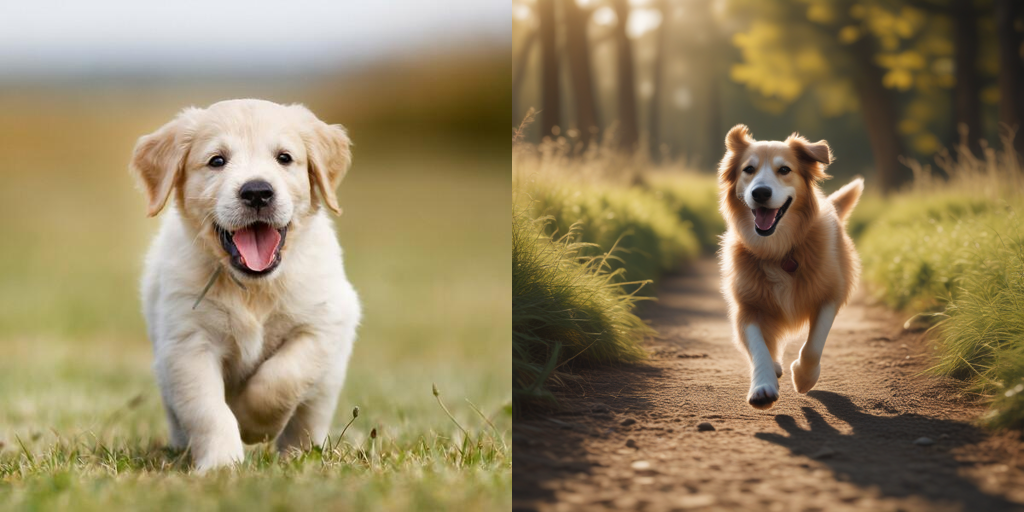

In [ ]:
#@title Resultado - Pipeline de Imagem para Imagem do SDXL Lightning

result_lightning = pipe_lightning(prompt, image=init_image, strength=0.5, guidance_scale=0.2, num_inference_steps=3).images[0]
result_lightning = result_lightning.resize((512, 512))
make_image_grid([init_image, result_lightning], rows=1, cols=2)


In [ ]:
#@title Pipeline de Imagem para Imagem do Hyper SDXL

%%capture hypersdxl
base_model_id = "stabilityai/stable-diffusion-xl-base-1.0"
repo_name = "ByteDance/Hyper-SD"

# Utilizando checkpoint Lora de 2 Steps de Inferência.
ckpt_name = "Hyper-SDXL-2steps-lora.safetensors"

# Carregando o modelo.
pipe_hyper = DiffusionPipeline.from_pretrained(base_model_id, torch_dtype=torch.float16, variant="fp16").to("cuda")
pipe_hyper.load_lora_weights(hf_hub_download(repo_name, ckpt_name))
pipe_hyper.fuse_lora()

# Selecionar trailing no parâmetro timestep spacing.
pipe_hyper.scheduler = DDIMScheduler.from_config(pipe_hyper.scheduler.config, timestep_spacing="trailing")


  0%|          | 0/2 [00:00<?, ?it/s]

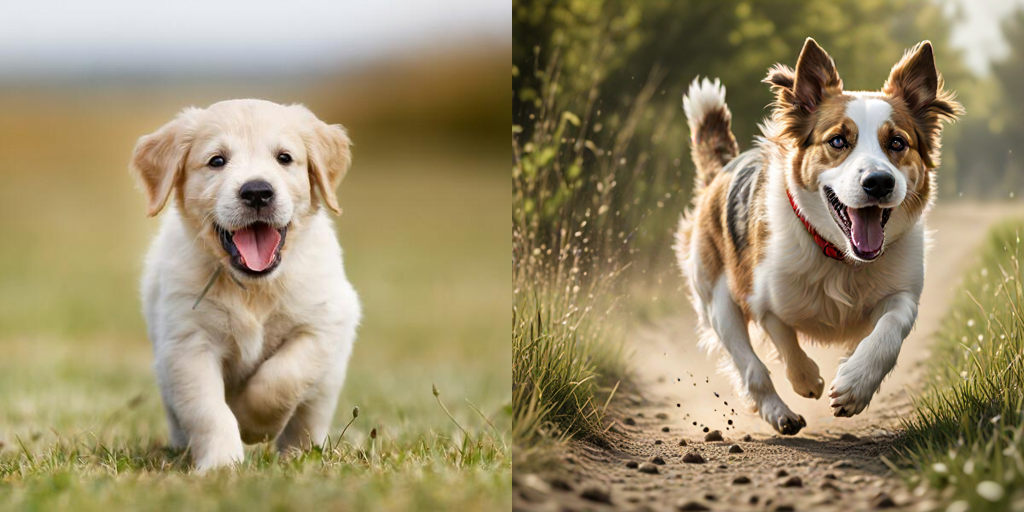

In [ ]:
#@title Resultado - Pipeline de Imagem para Imagem do Hyper SDXL

result_hyper = pipe_hyper(prompt, image=init_image, strength=0.5, guidance_scale=0, num_inference_steps=2).images[0]
result_hyper = result_hyper.resize((512, 512))
make_image_grid([init_image, result_hyper], rows=1, cols=2)


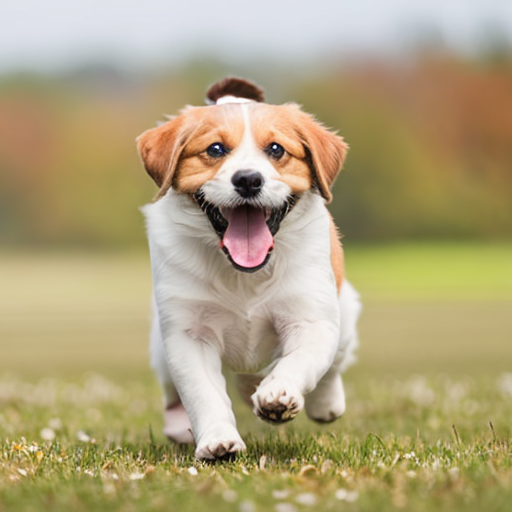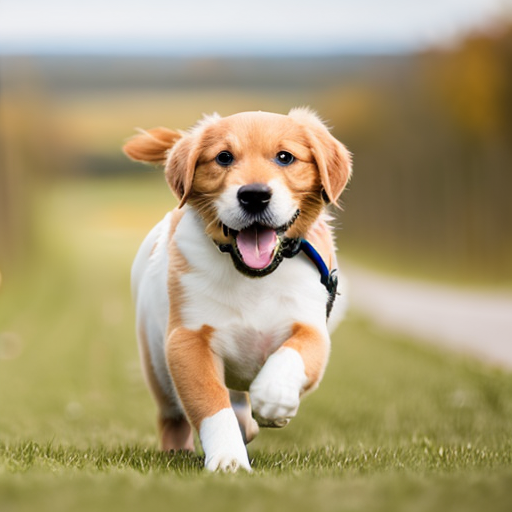

In [ ]:
from huggingface_hub import login
login()